# Network Science Assignment 5

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 28. October 2024

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob

In [2]:
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

For the provided network datasets find the communities using (a) the greedy modularity maximization by Clauset Newman and Moore and (b) the label propagation algorithm.
Assign to each community a color and draw the resulting graph, where each node is colored after the community it belongs to, while community internal links and inter‑communities links are clearly recognizable.


In [20]:
def greedy_modularity_maximization(G): 
    communities = nx.community.greedy_modularity_communities(G)
    return communities


def label_propagation(G):
    communities = nx.community.label_propagation_communities(G)
    return communities

In [21]:
#visualization
def initialize_visualization(ROWS, COLS): 
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS), dpi=300)
    return fig, axes

In [37]:
def community_figure(ROWS, COLS, data, title):
    fig, axes = initialize_visualization(ROWS, COLS)
    for i, G in enumerate(data):
        communities = [list(greedy_modularity_maximization(G)), list(label_propagation(G))]
        color_map = {}

        for r in range(len(communities)):
            # Define colors for communities
            for ii, community in enumerate(communities[r]):
                color = plt.cm.tab20(ii)
                for node in community:
                    color_map[node] = color

            # Draw graph
            pos = nx.spring_layout(G)
            nx.draw(G, 
                    pos, 
                    node_color=[color_map[node] for node in G.nodes()],
                    node_size=50, 
                    edgelist=G.edges(),
                    width=0.5,
                    edge_color=['black' if any(edge[0] in community and edge[1] in community for community in communities[r]) else 'lightgray' for edge in G.edges()],
                    ax=axes[i][r])
            
            modularity_score = nx.algorithms.community.quality.modularity(G, communities[r])
            axes[i][r].text(0.05, 0.95, f"Modularity: {modularity_score:.3f}", 
                            transform=axes[i][r].transAxes, fontsize=12,
                            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

            algo_name = "Greedy Modularity Maximization" if r == 0 else "Label Propagation"
            axes[i][r].set_title(f"{data_names[i]} - {algo_name}", fontsize=13)
            axes[i][r].axis('off')

        # Set main title
        fig.suptitle(title, fontsize=20, y=0.92)
        
    return communities[0], communities[1]


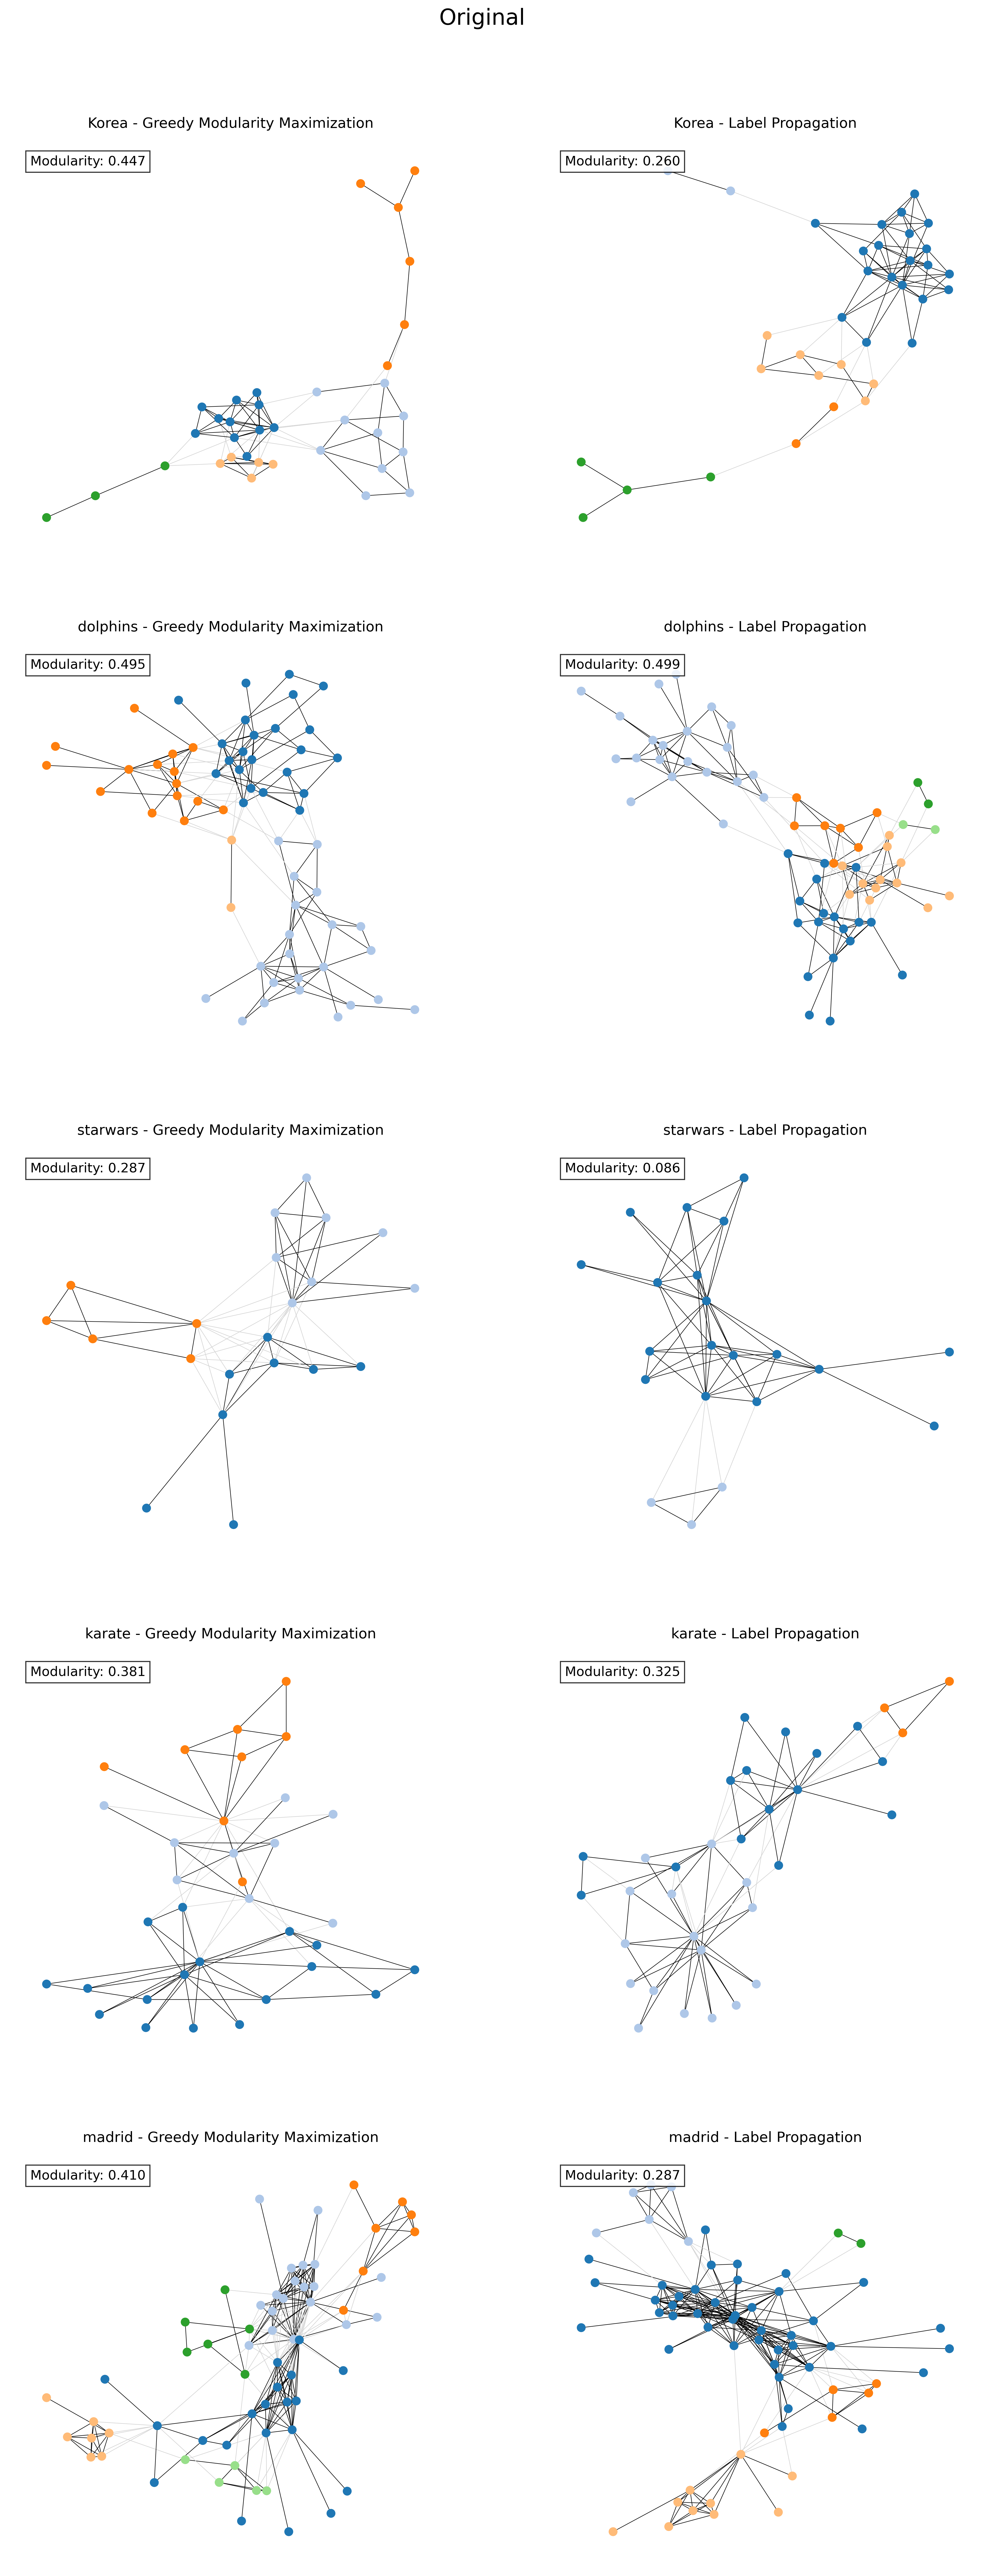

In [38]:
# a) greedy_modularity_maximization
communities_GMM, communities_LP= community_figure(5,2, data_lst, "Original")

## Task 2
Randomise each network and repeat the exercise at task 1.

In [43]:
# we perform degree preserving randomization of the data
data_lst_R = [nx.algorithms.smallworld.random_reference(G, connectivity=False) for G in data_lst]

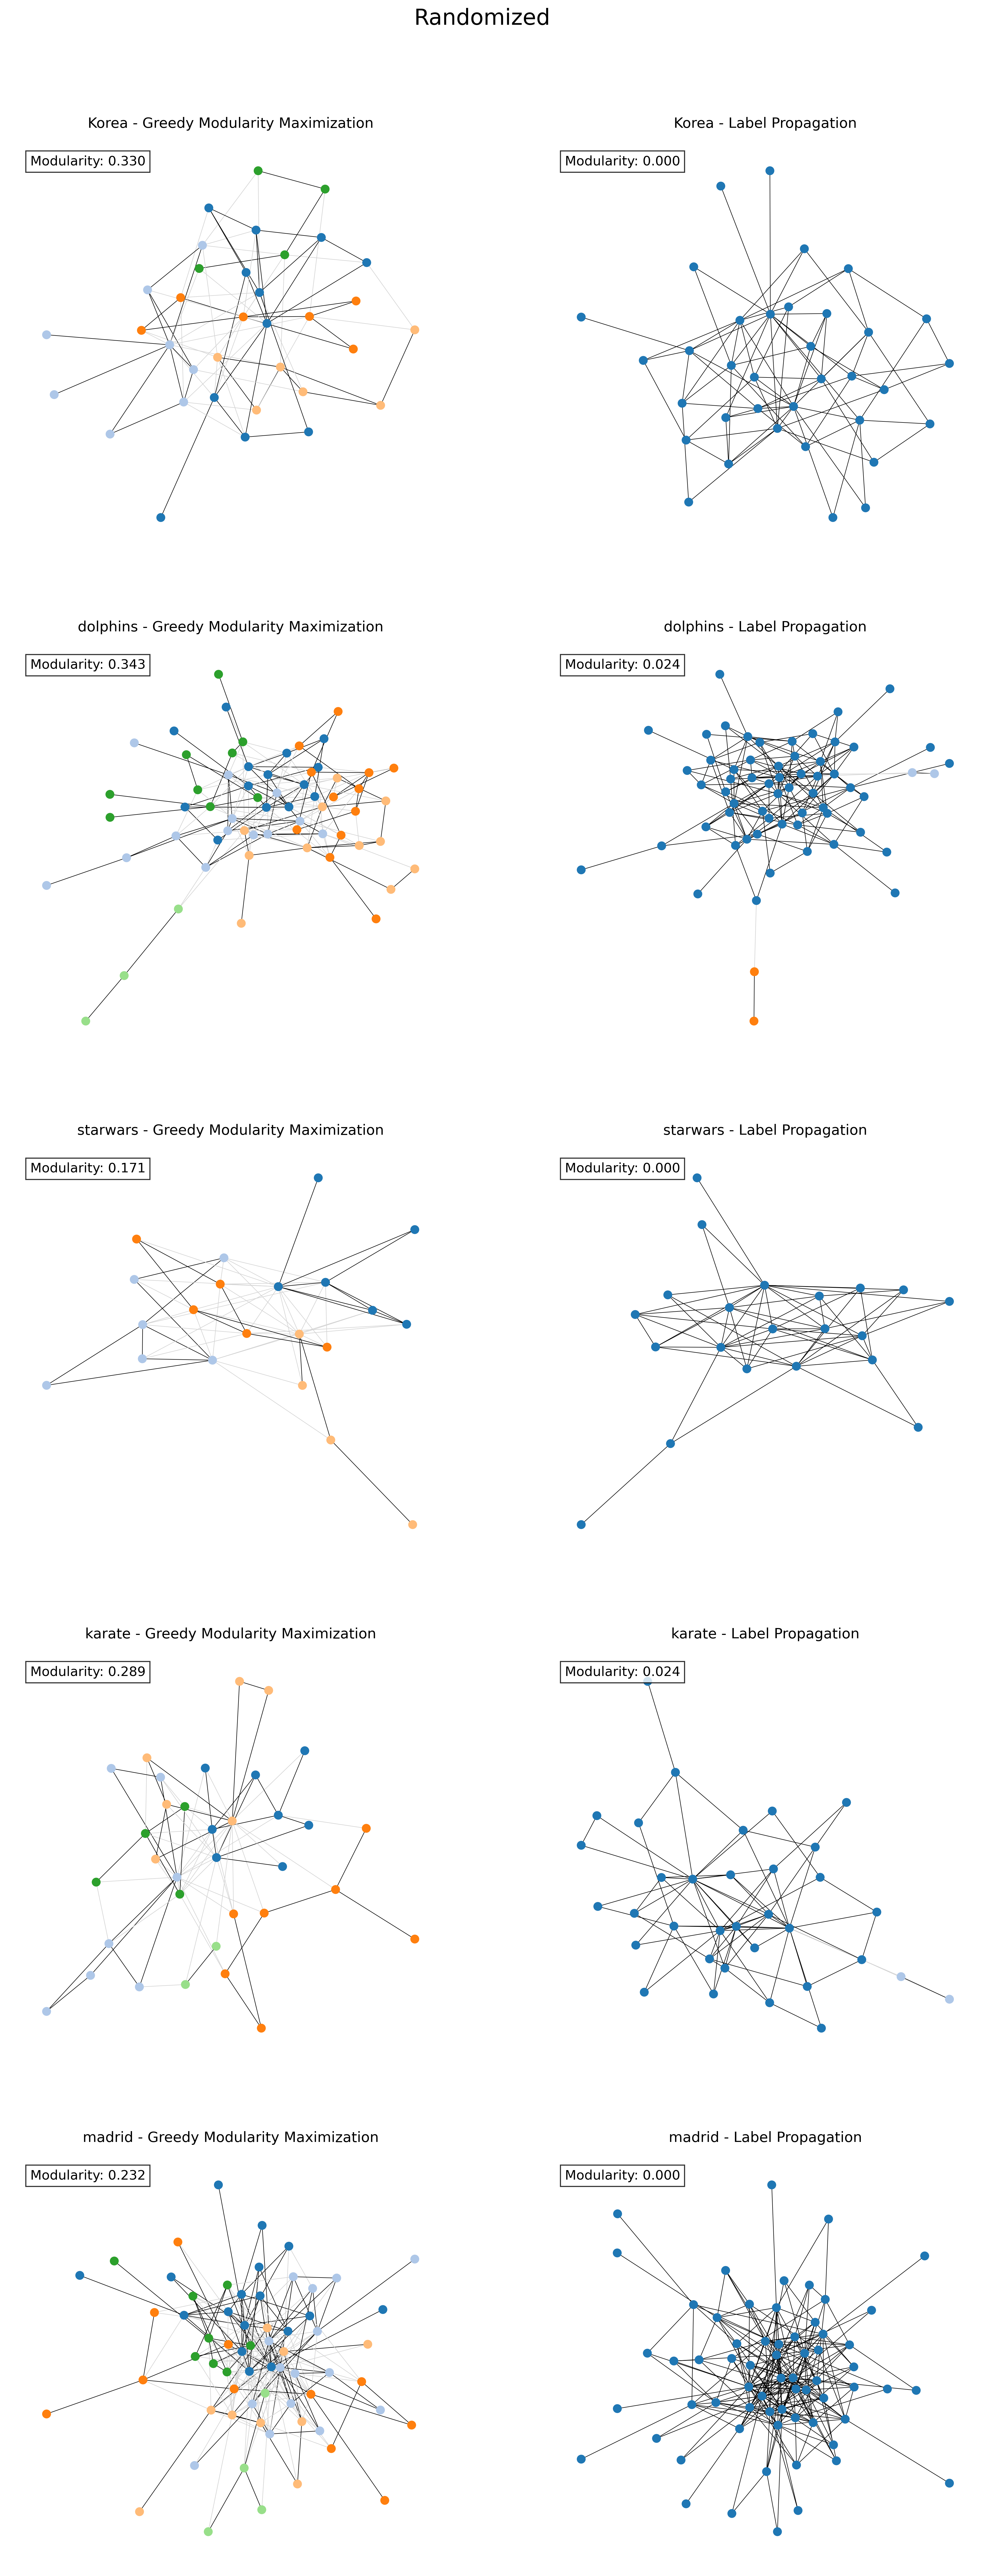

In [44]:
# 2a) greedy_modularity_maximization randomized
communities_GMM_R, communities_LP_R = community_figure(5,2, data_lst_R, "Randomized")

In [36]:
print(f"Greedy Modularity Maximization: {len(communities_GMM)} Communities with {[str(len(C)) for C in communities_GMM]}")
print(f"Greedy Modularity Maximization Randomized: {len(communities_GMM_R)} Communities with {[str(len(C)) for C in communities_GMM_R]}")
print(f"Label Propagation: {len(communities_LP)} Communities with {[str(len(C)) for C in communities_LP]}")
print(f"Label Propagation Randomized: {len(communities_LP_R)} Communities with {[str(len(C)) for C in communities_LP_R]}")


Greedy Modularity Maximization: 6 Communities with ['20', '19', '7', '7', '6', '5']
Greedy Modularity Maximization Randomized: 6 Communities with ['18', '16', '12', '8', '7', '3']
Label Propagation: 5 Communities with ['41', '6', '5', '10', '2']
Label Propagation Randomized: 2 Communities with ['62', '2']


### Interpretation
Compare the number of communities obtained before and after randomisation and the quality of community detection before and after randomisation.

Given the above analysis, the number of communities obtained before and after randomisation stays constant (6) for Greedy Modularity Maximization (GMM), while Label Propagation (LP) significantly decreases the number of communities detected after randomisation from 5 to 2. This implies that there is some inherent stability of GMM vice versa LP in randomized scenarios.

Some reasons for this discrepancy might include: 
- deterministic vs. stochastic: While GMM will produce stable results in most cases (excluding modularity gain ties), LP is stochastic by nature.
- global vs. local: GMM (greedily) optimizes on the global network, while LP is a local algorithm, determined by the local properties. As the randomization via edge swapping can drastically change the local neighborhoods of a node, this change can propagate during label assignment. On the other hand, the global approach of GMM, where it considers the merge of any communities and the degrees of the nodes vary, is less susceptible to variations in the local environment for community detection. Thus, while the nodes belonging to a community might change, the detection capabilities of GMM are more stable, and suited for community detection in randomized scenarios. 

Before randomization, however, the difference in community detection quality is less pronounced and neither of the algorithms is necessarily better. While the resulting modularity of the GMM algorithm is higher in most cases (here 4 out of 5), its greedy nature does not guarantee an optimal solution. Neither does LP, however, do to its stochastic nature, it can outperform GMM, in cases with inherent community structures, not susceptible to the propagation of a single label throughout the entire graph, e.g. if the communities have a high internal connectivity and some edges have a high betweenness centrality, which can avoid propagation of a single label throughout the network, or by considering partitions "overlooked" by the greedy nature of GMM.  


In short, randomization affects LP more severely, leading to a less clear partition, while GMM is resilient in maintaining community structure. This outcome may imply that GMM is better suited to detect stable community structures, even in randomized scenarios. In the non-randomized case however, these differences are less pronounced and if a network is not susceptible to single label dominance, LP can outperform GMM.